In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
PROJECT_ROOT = Path("..").resolve()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

model_base = pd.read_csv(PROCESSED_DATA_DIR / "rent_prediction_base.csv")
model_base.head()

,date_rent,area_code,area_name_rent,average_monthly_rent,date_house,area_name_house,average_house_price,area_name_key,median_annual_pay,income_confidence_pct,rent_to_income_ratio
0,2026-04-01,E06000001,Hartlepool,566,2026-04-01,Hartlepool,129129,hartlepool,28830.0,6.7,0.235588
1,2026-04-01,E06000002,Middlesbrough,709,2026-04-01,Middlesbrough,139005,middlesbrough,30253.0,5.5,0.281228
2,2026-04-01,E06000003,Redcar and Cleveland,644,2026-04-01,Redcar and Cleveland,154422,redcar and cleveland,28630.0,6.5,0.269927
3,2026-04-01,E06000004,Stockton-on-Tees,736,2026-04-01,Stockton-on-Tees,169540,stockton-on-tees,29877.0,6.9,0.295612
4,2026-04-01,E06000005,Darlington,671,2026-04-01,Darlington,156880,darlington,30100.0,8.4,0.267508


In [3]:
target = "average_monthly_rent"

features = [
    "average_house_price",
    "median_annual_pay"
]

In [4]:
X = model_base[features]
y = model_base[target]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [7]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

prediction_results = model_base.loc[X_test.index, [
    "area_code",
    "area_name_rent",
    "average_house_price",
    "median_annual_pay"
]].copy()

prediction_results["actual_rent"] = y_test
prediction_results["predicted_rent"] = linear_predictions
prediction_results["error"] = prediction_results["predicted_rent"] - prediction_results["actual_rent"]
prediction_results["absolute_error"] = prediction_results["error"].abs()

prediction_results.head()

,area_code,area_name_rent,average_house_price,median_annual_pay,actual_rent,predicted_rent,error,absolute_error
173,E07000175,Newark and Sherwood,236330,29806.0,789,896.404544,107.404544,107.404544
33,E06000036,Bracknell Forest,397667,36067.0,1499,1419.260873,-79.739127,79.739127
165,E07000147,North Norfolk,285303,28421.0,858,1019.482902,161.482902,161.482902
78,E07000043,North Devon,277169,28386.0,851,996.166245,145.166245,145.166245
93,E07000071,Colchester,298311,31589.0,1217,1090.521864,-126.478136,126.478136


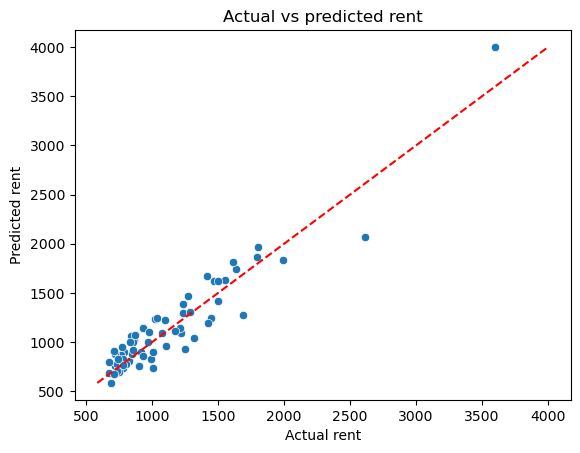

In [9]:
min_rent = prediction_results[["actual_rent", "predicted_rent"]].min().min()
max_rent = prediction_results[["actual_rent", "predicted_rent"]].max().max()

sns.scatterplot(
    data=prediction_results,
    x="actual_rent",
    y="predicted_rent"
)

plt.plot(
    [min_rent, max_rent],
    [min_rent, max_rent],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual rent")
plt.ylabel("Predicted rent")
plt.title("Actual vs predicted rent")
plt.show()

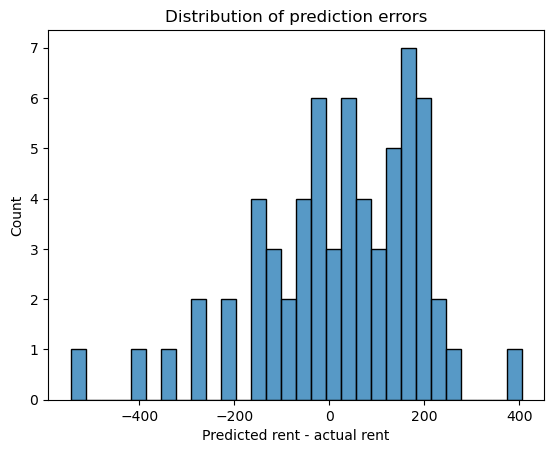

In [10]:
# Error distribution

sns.histplot(prediction_results["error"], bins=30)

plt.title("Distribution of prediction errors")
plt.xlabel("Predicted rent - actual rent")
plt.show()

In [11]:
# Worst underpredictions

prediction_results.sort_values("error").head(10)

,area_code,area_name_rent,average_house_price,median_annual_pay,actual_rent,predicted_rent,error,absolute_error
272,E09000012,Hackney,612501,40237.0,2615,2070.296058,-544.703942,544.703942
262,E09000002,Barking and Dagenham,360007,32911.0,1688,1278.835860,-409.164140,409.164140
42,E06000045,Southampton,234150,32907.0,1248,923.888222,-324.111778,324.111778
76,E07000041,Exeter,287013,29531.0,1313,1036.343139,-276.656861,276.656861
17,E06000018,Nottingham,192543,26512.0,1007,737.205356,-269.794644,269.794644
223,E07000243,Stevenage,319265,35747.0,1421,1194.704536,-226.295464,226.295464
24,E06000025,South Gloucestershire,338054,35002.0,1446,1239.607955,-206.392045,206.392045
265,E09000005,Brent,547995,34871.0,1990,1830.200026,-159.799974,159.799974
25,E06000026,Plymouth,216463,28992.0,989,831.553557,-157.446443,157.446443
132,E07000114,Thanet,263199,28323.0,1108,956.088982,-151.911018,151.911018


In [12]:
# Worst overpredictions

prediction_results.sort_values("error", ascending=False).head(10)

,area_code,area_name_rent,average_house_price,median_annual_pay,actual_rent,predicted_rent,error,absolute_error
280,E09000020,Kensington and Chelsea,1272760,46690.0,3597,4002.145225,405.145225,405.145225
111,E07000089,Hart,473396,39341.0,1414,1668.316429,254.316429,254.316429
82,E07000047,West Devon,307291,26556.0,837,1061.260525,224.260525,224.260525
63,E07000009,East Cambridgeshire,338848,34311.0,1018,1234.352902,216.352902,216.352902
218,E07000238,Wychavon,323344,29661.0,929,1140.202835,211.202835,211.202835
104,E07000082,Stroud,345405,33495.0,1039,1243.993283,204.993283,204.993283
300,W06000008,Ceredigion,244182,29326.0,709,913.340695,204.340695,204.340695
90,E07000068,Brentwood,523144,39864.0,1610,1814.272910,204.272910,204.272910
77,E07000042,Mid Devon,291923,31908.0,872,1075.967966,203.967966,203.967966
179,E07000181,West Oxfordshire,418246,35388.0,1273,1469.927700,196.927700,196.927700


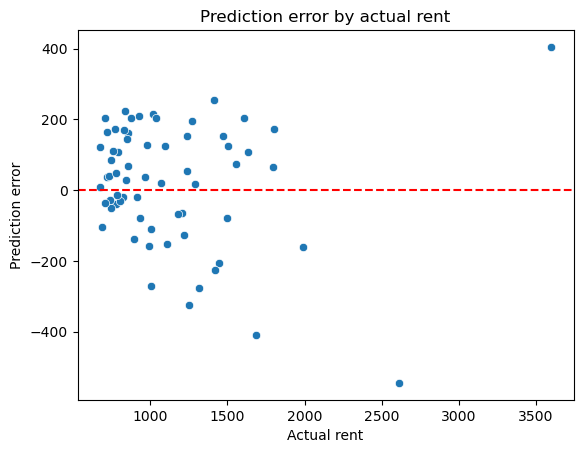

In [13]:
# Error vs actual rent

sns.scatterplot(
    data=prediction_results,
    x="actual_rent",
    y="error"
)

plt.axhline(0, color="red", linestyle="--")
plt.title("Prediction error by actual rent")
plt.xlabel("Actual rent")
plt.ylabel("Prediction error")
plt.show()

## Error analysis notes

The linear regression model performs much better than the baseline, but it still has notable errors in some areas.

Negative errors indicate underprediction, where actual rents are higher than predicted. Positive errors indicate overprediction.

The largest errors suggest that house price and income alone do not capture all local rental market differences. Additional features such as region, property mix, population density, student population, or commuting access may improve the model.

## Add region as a feature so the model can learn that rents differ systematically by part of the country:

In [14]:
model_base.columns

Index(['date_rent', 'area_code', 'area_name_rent', 'average_monthly_rent',
       'date_house', 'area_name_house', 'average_house_price', 'area_name_key',
       'median_annual_pay', 'income_confidence_pct', 'rent_to_income_ratio'],
      dtype='object')